This notebook attempts to quantify phoneme distance based on Cochlea Simulation using [CoNNear](https://github.com/HearingTechnology/CoNNear_cochlea) on the Phoneme Voice Files from [Best Phonetic Alphabet](https://github.com/Jumplion/Best-Phonetic-Alphabet) by Jumplion.

Adapted by Daniel Fernandes from the CoNNear reproduction notebook.

## Prerequisites

Git clone the CoNNear repository linked above, and place this notebook at its root. Also copy the `Phoneme Voice Files` folder from the Best Phonetic Alphabet repository to the same location, and rename it to `ph`. 

Ensure that conda is installed (miniconda is fine), then run these commands:

```shell
conda create -n connear python=3.6 -y
conda activate connear
conda install numpy=1.18.1 scipy=1.4.1 -y
pip install tensorflow==1.13.2
pip install keras==2.3.1
conda install h5py==2.10.0
```

Also make sure that you are using this notebook in this newly created `connear` environment. You may continue with these commands to do that:

```shell
conda install jupyter
jupyter notebook
```

In [2]:
# preliminary setup stuff

import os

import numpy as np
from scipy import signal
import scipy.signal as sp_sig
import matplotlib.pyplot as plt
import keras
from keras.models import model_from_json
from keras.utils import CustomObjectScope
from keras.initializers import glorot_uniform

from helper_ops import *

json_file = open("connear/Gmodel.json", "r")
loaded_model_json = json_file.read()
json_file.close()
with CustomObjectScope({'GlorotUniform': glorot_uniform()}):    
    connear = model_from_json(loaded_model_json)
with CustomObjectScope({'GlorotUniform': glorot_uniform()}):
     connear.load_weights("connear/Gmodel.h5")
connear.summary()

Using TensorFlow backend.
C:\Users\Daniel\miniconda3\envs\connear\lib\site-packages\tensorflow\python\framework\dtypes.py:526: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
C:\Users\Daniel\miniconda3\envs\connear\lib\site-packages\tensorflow\python\framework\dtypes.py:527: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
C:\Users\Daniel\miniconda3\envs\connear\lib\site-packages\tensorflow\python\framework\dtypes.py:528: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
C:\Users\Daniel\miniconda3\envs\con

Instructions for updating:
Colocations handled automatically by placer.
Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
audio_input (InputLayer)     (None, None, 1)           0         
_________________________________________________________________
model_1 (Model)              (None, None, 201)         11689984  
Total params: 11,689,984
Trainable params: 11,689,984
Non-trainable params: 0
_________________________________________________________________


In [3]:
# Define model specific variables
down_rate = 2
fs = 20e3
fs_tl = 100e3
factor_fs = int(fs_tl / fs)
p0 = 2e-5
right_context = 256
left_context = 256
# load CFs 
CF = np.loadtxt('tlmodel/cf.txt')
channels = CF.size 

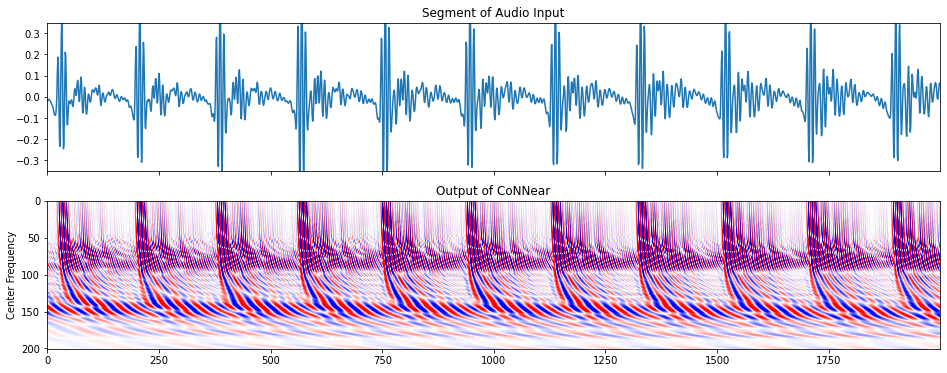

In [4]:
#load in just one audio clip

stim = None # we'll use this for plotting below
def wav_to_connear(wavfile_path):
    global stim
    # Read the WAV file
    signal_wav, fs_signal = wavfile_read(wavfile_path)
    
    # Resample to target fs_tl
    signalr = sp_sig.resample_poly(signal_wav, fs_tl, fs_signal)
    
    # sound-level of 70 dB SPL
    L=np.array([70])
    stim_full = np.zeros((len(L), signalr.size))
    for j in range(len(L)):
        stim_full[j, :] = p0 * 10**(L[j]/20) * signalr / rms(signalr)

    # Define fragment length
    fragment_length = 2000
    stim_length_init = factor_fs * (fragment_length + right_context + left_context)
    
    # adapt fragment duration if no multiple of 16 (due to the CNN character of CoNNear, we need multiples of 16)
    zero_pad = fragment_length % 16
    zeros = 16 - zero_pad if zero_pad != 0 else 0
    stim_length = factor_fs * (fragment_length + right_context + left_context + zeros)

    # Prepare stimulus
    stim = np.zeros((len(L), int(stim_length)))
    stimrange = range(0, stim_length_init)
    stim[:, stimrange] = stim_full[:, 0:stim_length_init]
    stim = sp_sig.resample_poly(stim, fs, fs_tl, axis=1)
    stim = np.expand_dims(stim, axis=2)

    # Run model prediction
    tl_pred = connear.predict(stim)
    return tl_pred[0, :, :].T



test_phoneme = 'ph/EY/EY_02.wav'

connear_pred = wav_to_connear(test_phoneme)

fig, axarr = plt.subplots(2, sharex=True, figsize=(16, 6))
axarr[0].set_ylim(-0.35, 0.35)
axarr[0].plot(stim[0,(left_context):-(right_context),0])
axarr[0].set_title('Segment of Audio Input')

cax2 = axarr[1].imshow(connear_pred, cmap='bwr',aspect='auto', vmin=-0.5, vmax=0.5)  
axarr[1].set_title('Output of CoNNear')
axarr[1].set(ylabel='Center Frequency')

plt.show()

In [5]:


# Collect all .wav files in 'ph/' recursively
wav_files = []
for root, _, files in os.walk("ph"):
    for file in files:
        if file.endswith(".wav"):
            wav_files.append(os.path.join(root, file))

# Run the function on each clip and store results
results = {}
for wav_path in wav_files:
    print(wav_path)
    try:
        results[wav_path] = wav_to_connear(wav_path)
    except:
        print("^skipped")

ph\AA\AA_01.wav
ph\AA\AA_02.wav
ph\AA\AA_05.wav
ph\AA\AA_06.wav
ph\AA\AA_07.wav
ph\AA\AA_09.wav
ph\AA\AA_10.wav
ph\AA\AA_12.wav
ph\AA\AA_13.wav
ph\AA\AA_18.wav
ph\AA\AA_medoid.wav
ph\AA\AA_normalized.wav
ph\AE\AE_01.wav
ph\AE\AE_02.wav
ph\AE\AE_04.wav
ph\AE\AE_05.wav
ph\AE\AE_06.wav
ph\AE\AE_07.wav
ph\AE\AE_09.wav
ph\AE\AE_10.wav
ph\AE\AE_11.wav
ph\AE\AE_medoid.wav
ph\AE\AE_normalized.wav
ph\AH\AH_01.wav
ph\AH\AH_02.wav
ph\AH\AH_03.wav
ph\AH\AH_04.wav
ph\AH\AH_05.wav
ph\AH\AH_06.wav
ph\AH\AH_07.wav
ph\AH\AH_08.wav
ph\AH\AH_09.wav
ph\AH\AH_10.wav
ph\AH\AH_11.wav
ph\AH\AH_medoid.wav
ph\AH\AH_normalized.wav
ph\AO\AO_01.wav
ph\AO\AO_02.wav
ph\AO\AO_03.wav
ph\AO\AO_04.wav
ph\AO\AO_05.wav
ph\AO\AO_07.wav
ph\AO\AO_08.wav
ph\AO\AO_10.wav
ph\AO\AO_12.wav
ph\AO\AO_14.wav
ph\AO\AO_average.wav
ph\AO\AO_medoid.wav
ph\AO\AO_normalized.wav
ph\AW\AW_medoid.wav
ph\AW\AW_normalized.wav
ph\AX\AX_01.wav
ph\AX\AX_02.wav
ph\AX\AX_03.wav
ph\AX\AX_05.wav
ph\AX\AX_06.wav
ph\AX\AX_07.wav
ph\AX\AX_09.wav
ph\AX\A

ph\W\W_06.wav
^skipped
ph\W\W_07.wav
ph\W\W_09.wav
ph\W\W_10.wav
ph\W\W_13.wav
ph\W\W_17.wav
ph\W\W_19.wav
ph\W\W_21.wav
ph\W\W_average.wav
ph\W\W_medoid.wav
ph\W\W_normalized.wav
ph\Y\Y_01.wav
ph\Y\Y_02.wav
ph\Y\Y_03.wav
ph\Y\Y_04.wav
ph\Y\Y_05.wav
ph\Y\Y_06.wav
ph\Y\Y_07.wav
ph\Y\Y_08.wav
ph\Y\Y_09.wav
ph\Y\Y_11.wav
ph\Y\Y_12.wav
ph\Y\Y_13.wav
ph\Y\Y_14.wav
ph\Y\Y_15.wav
ph\Y\Y_average.wav
ph\Y\Y_medoid.wav
ph\Y\Y_normalized.wav
ph\Z\Z_medoid.wav
ph\Z\Z_normalized.wav
ph\ZH\ZH_01.wav
ph\ZH\ZH_03.wav
ph\ZH\ZH_04.wav
ph\ZH\ZH_05.wav
ph\ZH\ZH_06.wav
ph\ZH\ZH_07.wav
ph\ZH\ZH_08.wav
ph\ZH\ZH_09.wav
ph\ZH\ZH_10.wav
ph\ZH\ZH_11.wav
ph\ZH\ZH_12.wav
ph\ZH\ZH_13.wav
ph\ZH\ZH_medoid.wav
ph\ZH\ZH_normalized.wav


In [45]:
# the following blocks are for saving / loading the results, they are optional to use.
import pickle

# Save the results dictionary to disk
with open("results.pkl", "wb") as f:
    pickle.dump(results, f)

In [2]:
import pickle

with open("results.pkl", "rb") as f:
    results = pickle.load(f)

In [9]:
# map a clip to every phoneme

import re
from collections import defaultdict

phoneme_to_files = defaultdict(list)
pattern = re.compile(r'ph\\([^/]+)\\([^/]+)\.wav')

for path in results.keys():
    match = pattern.match(path)
    if match:
        phoneme, filename = match.groups()
        if 'normalized' not in filename and 'average' not in filename:
            phoneme_to_files[phoneme].append(f'ph\\{phoneme}\\{filename}.wav')

phoneme_to_clip = {}

for phoneme, files in phoneme_to_files.items():
    medoid_file = f'ph\\{phoneme}\\{phoneme}_medoid.wav'
    
    if medoid_file in files:
        phoneme_to_clip[phoneme] = medoid_file
    else:
        # Look for numbered files like PH_01.wav
        numbered = sorted(
            (f for f in files if re.match(rf'ph\\{phoneme}\\{phoneme}_[0-9]+\.wav', f)),
            key=lambda x: int(re.findall(r'_(\d+)\.wav', x)[0])
        )
        if numbered:
            fallback = numbered[0]
            phoneme_to_clip[phoneme] = fallback
            print(f"[INFO] No medoid for phoneme '{phoneme}'. Using fallback: {fallback}")
        else:
            print(f"[WARNING] No valid file found for phoneme '{phoneme}'.")



[INFO] No medoid for phoneme 'HH'. Using fallback: ph\HH\HH_02.wav
[INFO] No medoid for phoneme 'K'. Using fallback: ph\K\K_01.wav
[INFO] No medoid for phoneme 'P'. Using fallback: ph\P\P_02.wav
[INFO] No medoid for phoneme 'T'. Using fallback: ph\T\T_01.wav


In [10]:
phoneme_to_clip

{'AA': 'ph\\AA\\AA_medoid.wav',
 'AE': 'ph\\AE\\AE_medoid.wav',
 'AH': 'ph\\AH\\AH_medoid.wav',
 'AO': 'ph\\AO\\AO_medoid.wav',
 'AW': 'ph\\AW\\AW_medoid.wav',
 'AX': 'ph\\AX\\AX_medoid.wav',
 'AY': 'ph\\AY\\AY_medoid.wav',
 'B': 'ph\\B\\B_medoid.wav',
 'CH': 'ph\\CH\\CH_medoid.wav',
 'D': 'ph\\D\\D_medoid.wav',
 'DH': 'ph\\DH\\DH_medoid.wav',
 'EH': 'ph\\EH\\EH_medoid.wav',
 'ER': 'ph\\ER\\ER_medoid.wav',
 'EY': 'ph\\EY\\EY_medoid.wav',
 'F': 'ph\\F\\F_medoid.wav',
 'G': 'ph\\G\\G_medoid.wav',
 'HH': 'ph\\HH\\HH_02.wav',
 'IH': 'ph\\IH\\IH_medoid.wav',
 'IY': 'ph\\IY\\IY_medoid.wav',
 'JH': 'ph\\JH\\JH_medoid.wav',
 'K': 'ph\\K\\K_01.wav',
 'L': 'ph\\L\\L_medoid.wav',
 'M': 'ph\\M\\M_medoid.wav',
 'N': 'ph\\N\\N_medoid.wav',
 'NG': 'ph\\NG\\NG_medoid.wav',
 'OW': 'ph\\OW\\OW_medoid.wav',
 'OY': 'ph\\OY\\OY_medoid.wav',
 'P': 'ph\\P\\P_02.wav',
 'R': 'ph\\R\\R_medoid.wav',
 'S': 'ph\\S\\S_medoid.wav',
 'SH': 'ph\\SH\\SH_medoid.wav',
 'T': 'ph\\T\\T_01.wav',
 'TH': 'ph\\TH\\TH_medoid.wa

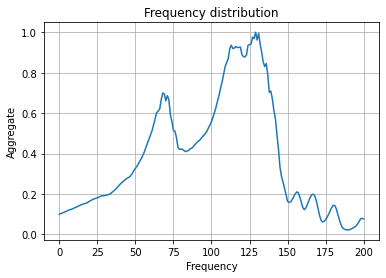

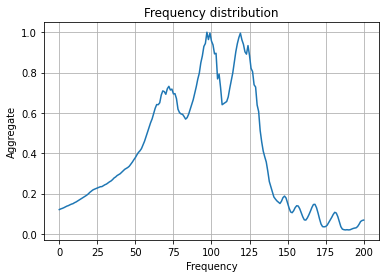

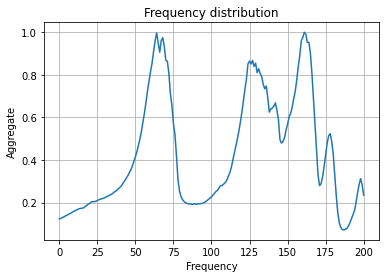

In [15]:
# sum all the values across the time axis (aka, collapse the time axis)

import numpy as np
import matplotlib.pyplot as plt

def aggregate(spectrogram):
    summed_array = np.sum(np.abs(spectrogram), axis=1)
    normalized_array = summed_array / np.max(summed_array)
    
    return normalized_array


def plot_agg(agg):
    plt.plot(agg)
    plt.xlabel('Frequency')
    plt.ylabel('Aggregate')
    plt.title('Frequency distribution')
    plt.grid(True)
    plt.show()

# let's see what this looks like for a few phonemes

plot_agg(aggregate(results[phoneme_to_clip['AA']]))
plot_agg(aggregate(results[phoneme_to_clip['AE']]))
plot_agg(aggregate(results[phoneme_to_clip['L']]))

# notice how AA and AE look similar, while L looks different

In [17]:
# compute euclidean distances, considering each frequency component as a dimension of the vector space

phonemes = list(phoneme_to_clip.keys())

csv_arr = []

for a in range(0, len(phonemes)):
    for b in range(a, len(phonemes)):
        phon_a = phonemes[a]
        phon_b = phonemes[b]
        file_a = phoneme_to_clip[phon_a]
        file_b = phoneme_to_clip[phon_b]
        dist_a = aggregate(results[file_a])
        dist_b = aggregate(results[file_b])
        distance = np.linalg.norm(dist_a - dist_b)
        csv_arr.append([phon_a, phon_b, distance])
        
csv_arr

[['AA', 'AA', 0.0],
 ['AA', 'AE', 2.4555676],
 ['AA', 'AH', 1.9509664],
 ['AA', 'AO', 1.5581272],
 ['AA', 'AW', 1.7006434],
 ['AA', 'AX', 1.3301138],
 ['AA', 'AY', 1.7174171],
 ['AA', 'B', 3.1284163],
 ['AA', 'CH', 6.341011],
 ['AA', 'D', 4.7160797],
 ['AA', 'DH', 4.4138865],
 ['AA', 'EH', 3.3227673],
 ['AA', 'ER', 2.3410394],
 ['AA', 'EY', 4.4743],
 ['AA', 'F', 5.187408],
 ['AA', 'G', 4.7501335],
 ['AA', 'HH', 3.934979],
 ['AA', 'IH', 4.614338],
 ['AA', 'IY', 5.3446355],
 ['AA', 'JH', 5.1696362],
 ['AA', 'K', 4.028304],
 ['AA', 'L', 4.17396],
 ['AA', 'M', 4.7971106],
 ['AA', 'N', 5.07193],
 ['AA', 'NG', 4.3452244],
 ['AA', 'OW', 2.5678706],
 ['AA', 'OY', 3.8574545],
 ['AA', 'P', 2.2820568],
 ['AA', 'R', 2.3410394],
 ['AA', 'S', 6.6864862],
 ['AA', 'SH', 5.4382586],
 ['AA', 'T', 5.5190334],
 ['AA', 'TH', 5.1087184],
 ['AA', 'UH', 3.3391254],
 ['AA', 'UW', 4.475244],
 ['AA', 'V', 3.8252902],
 ['AA', 'W', 4.7053876],
 ['AA', 'Y', 5.6455607],
 ['AA', 'Z', 6.012351],
 ['AA', 'ZH', 5.211886

In [ ]:
# save the results to a CSV file

import csv

with open('phoneme_audio_distance.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['From', 'To', 'Distance'])
    writer.writerows(csv_arr)